In [1]:
import numpy as np
from sklearn.feature_selection import f_classif


def compute_sensor_scores(dataloader):
    """
    Computes ANOVA F-scores per sensor using ONLY training data.
    """

    all_features = []
    all_labels = []

    for x, y, _ in dataloader:

        x = x.numpy()
        y = y.numpy()
        
        sensor_features = x.mean(axis=2)

        all_features.append(sensor_features)
        all_labels.append(y)

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)

    scores, _ = f_classif(X, y)

    return scores


def get_top_k_sensors(f_scores, top_k=50):
    indices = np.argsort(f_scores)[::-1].copy()
    return indices[:top_k]

In [2]:
class SensorSelector:
    def __init__(self, sensor_indices):
        self.sensor_indices = sensor_indices

    def __call__(self, x):
        return x[self.sensor_indices, :]

In [3]:
import torch

from dataset import create_dataloaders, SensorFilteredDataset
from tcn_model import MEGTCN
from gan_model import MHEGAN
from gan_model_simple import MEGGAN
from mlp_model import MLP
from cnn_baseline_1d import CNNBaseline1D
from evaluate import compare_models
from torch.utils.data import ConcatDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [5]:
BATCH_SIZE = 8
INTRA_DATA_DIR = "preprocessed_data/Intra"
intra_train_loader, intra_test_loader = create_dataloaders(INTRA_DATA_DIR, BATCH_SIZE, add_person_id=True)

intra_train_dataset = intra_train_loader.dataset
intra_test_dataset = intra_test_loader.dataset

Loading test data...
Loading train data...
Loaded 32 training samples
Loaded 8 test samples
Class distribution in training: [8 8 8 8]
Class distribution in test: [2 2 2 2]
Train batches: 4
Test batches: 1


In [6]:
scores = compute_sensor_scores(intra_train_loader)

top50 = get_top_k_sensors(scores, 50)
top100 = get_top_k_sensors(scores, 100)
top150 = get_top_k_sensors(scores, 150)
top200 = get_top_k_sensors(scores, 200)

In [ ]:
intra_model_configs = [
    {
        "name": "MLP",
        "model_class": MLP,
        "params": {'learning_rate': 0.0005, 'dropout': 0.05, 'hidden_size': 64, 'batch_size': 8},
    },
    {
        "name": "CNN",
        "model_class": CNNBaseline1D,
        "params": {"learning_rate": 1e-3, "kernel_size": 5, "dropout": 0.05, "hidden_channels": 16, "batch_size": 8},
    },
    {
        "name": "TCN",
        "model_class": MEGTCN,
        "params": {'learning_rate': 0.0001, 'kernel_size': 7, 'dropout': 0.05, 'hidden_channels': 64, 'batch_size': 8},
    },
    {
        "name": "GAN_simple",
        "model_class": MEGGAN,
        "params": {'learning_rate': 0.005, 'hidden_channels': 32, 'kernel_size': 3, 'dropout': 0.1, 'num_heads': 2, 'weight_decay': 0.0001, 'batch_size': 8},
    },
    {
        "name": "GAN",
        "model_class": MHEGAN,
        "params": {'learning_rate': 0.005, 'hidden_channels': 64, 'kernel_size': 7, 'dropout': 0.2, 'num_heads': 2, 'weight_decay': 0.0001, 'batch_size': 8},
    },
]

In [8]:
sensor_scenarios = {
    "all": None,
    "top200": top200,
    "top150": top150,
    "top100": top100,
    "top50": top50,
}

intra_results = compare_models(
    intra_model_configs,
    intra_train_dataset,
    intra_test_dataset,
    num_classes=4,
    device=DEVICE,
    sensor_scenarios=sensor_scenarios,
    epochs=20,
    n_runs=5
)


MODEL: MLP

--------------------------------------------------
SENSOR SET: all
--------------------------------------------------
Scenario=all, Sensors=248
Run 1/5 | Acc: 100.00%
Scenario=all, Sensors=248
Run 2/5 | Acc: 100.00%
Scenario=all, Sensors=248
Run 3/5 | Acc: 100.00%
Scenario=all, Sensors=248
Run 4/5 | Acc: 100.00%
Scenario=all, Sensors=248
Run 5/5 | Acc: 100.00%

--------------------------------------------------
SENSOR SET: top200
--------------------------------------------------
Scenario=top200, Sensors=200
Run 1/5 | Acc: 100.00%
Scenario=top200, Sensors=200
Run 2/5 | Acc: 100.00%
Scenario=top200, Sensors=200
Run 3/5 | Acc: 100.00%
Scenario=top200, Sensors=200
Run 4/5 | Acc: 100.00%
Scenario=top200, Sensors=200
Run 5/5 | Acc: 100.00%

--------------------------------------------------
SENSOR SET: top150
--------------------------------------------------
Scenario=top150, Sensors=150
Run 1/5 | Acc: 100.00%
Scenario=top150, Sensors=150
Run 2/5 | Acc: 100.00%
Scenario=top150,

In [9]:
rows = []

for r in intra_results:
    model_name = r["model"]

    for scenario, stats in r["results"].items():
        rows.append({
            "model": model_name,
            "scenario": scenario,
            "acc_mean": stats["acc_mean"],
            "acc_std": stats["acc_std"],
        })

df = pd.DataFrame(rows)

scenarios = df["scenario"].unique()
models = df["model"].unique()

x = np.arange(len(scenarios))
width = 0.8 / len(models)

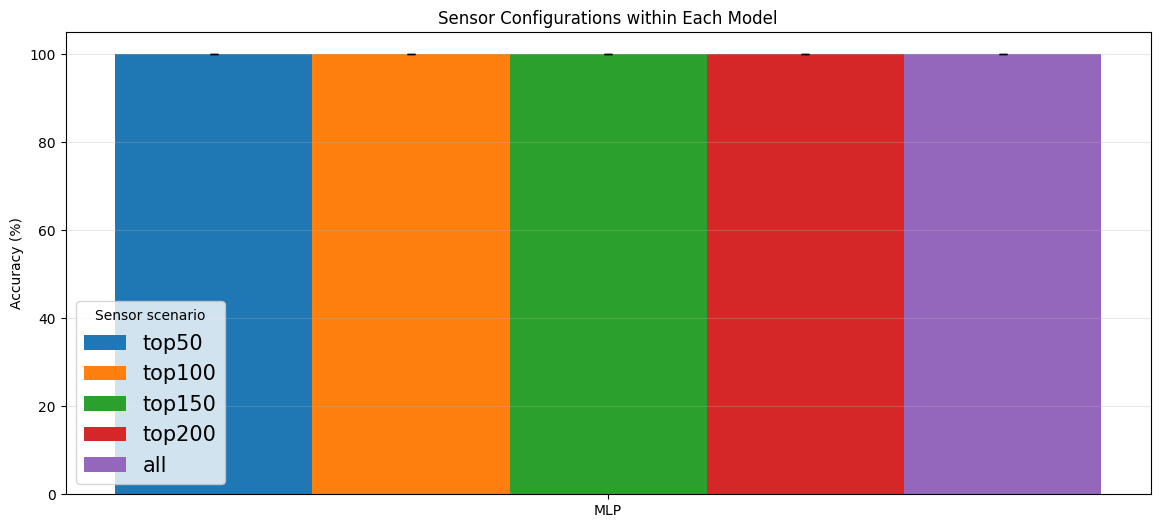

In [10]:
scenario_order = ["top50", "top100", "top150", "top200", "all"]
scenarios = [s for s in scenario_order if s in df["scenario"].unique()]

x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(14, 6))

for i, scenario in enumerate(scenarios):
    values = []

    for model in models:
        val = df[
            (df["model"] == model) &
            (df["scenario"] == scenario)
        ]["acc_mean"].values

        values.append(val[0] if len(val) > 0 else 0)

    plt.bar(
        x + i * width,
        values,
        width,
        yerr=[
            df[(df["model"] == m) & (df["scenario"] == scenario)]["acc_std"].values[0]
            if len(df[(df["model"] == m) & (df["scenario"] == scenario)]) > 0
            else 0
            for m in models
        ],
        capsize=3,
        label=scenario
    )

plt.xticks(x + width * (len(scenarios) - 1) / 2, models)
plt.ylabel("Accuracy (%)")
plt.title("Sensor Configurations within Each Model")
plt.legend(title="Sensor scenario", loc='lower left', fontsize = 15)
plt.grid(axis="y", alpha=0.3)

plt.show()

# Compare on cross dataset

In [11]:
import numpy as np
from sklearn.feature_selection import f_classif


def compute_sensor_scores(dataloader):
    """
    Computes temporal ANOVA F-scores per sensor using ONLY training data.
    """

    all_x = []
    all_y = []

    for x, y, _ in dataloader:

        all_x.append(x.numpy())
        all_y.append(y.numpy())

    X = np.concatenate(all_x, axis=0)
    y = np.concatenate(all_y, axis=0)

    n_samples, n_sensors, n_time = X.shape

    sensor_scores = np.zeros(n_sensors)

    for sensor in range(n_sensors):

        sensor_signal = X[:, sensor, :]

        # ANOVA separately for each timestep
        f_scores, _ = f_classif(sensor_signal, y)

        # Combine timesteps into one score
        sensor_scores[sensor] = np.percentile(f_scores, 90)

    return sensor_scores


def get_top_k_sensors(f_scores, top_k=50):

    indices = np.argsort(f_scores)[::-1].copy()

    return indices[:top_k]

In [12]:
class SensorSelector:
    def __init__(self, sensor_indices):
        self.sensor_indices = sensor_indices

    def __call__(self, x):
        return x[self.sensor_indices, :]

In [13]:
BATCH_SIZE = 8
CROSS_DATA_DIR = "preprocessed_data/Cross"
cross_train_loader, cross_test_loader = create_dataloaders(CROSS_DATA_DIR, BATCH_SIZE, add_person_id=True)

combined_train_dataset = ConcatDataset([
    intra_train_loader.dataset,
    cross_train_loader.dataset
])

combined_train_loader = DataLoader(
    combined_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

Loading test1 data...
Loading test2 data...
Loading test3 data...
Loading train data...
Loaded 64 training samples
Loaded 48 test samples
Class distribution in training: [16 16 16 16]
Class distribution in test: [12 12 12 12]
Train batches: 8
Test batches: 6


In [ ]:
cross_model_configs = [
    {
        "name": "MLP",
        "model_class": MLP,
        "params": {'learning_rate': 0.0005, 'dropout': 0.05, 'hidden_size': 64, 'batch_size': 8},
        "epochs": 7
    },
    {
        "name": "CNN",
        "model_class": CNNBaseline1D,
        "params": {"learning_rate": 1e-3, "kernel_size": 5, "dropout": 0.05, "hidden_channels": 16, "batch_size": 8},
        "epochs": 29
    },
    {
        "name": "TCN",
        "model_class": MEGTCN,
        "params": {'learning_rate': 0.0001, 'kernel_size': 7, 'dropout': 0.05, 'hidden_channels': 64, 'batch_size': 8},
        "epochs": 25
    },
    {
        "name": "GAN_simple",
        "model_class": MEGGAN,
        "params": {'learning_rate': 0.005, 'hidden_channels': 32, 'kernel_size': 3, 'dropout': 0.1, 'num_heads': 2, 'weight_decay': 0.0001, 'batch_size': 8},
        "epochs": 25
    },
    {
        "name": "GAN",
        "model_class": MHEGAN,
        "params": {'learning_rate': 0.005, 'hidden_channels': 64, 'kernel_size': 7, 'dropout': 0.2, 'num_heads': 2, 'weight_decay': 0.0001, 'batch_size': 8},
        "epochs": 25
    },
]

In [15]:
scores = compute_sensor_scores(combined_train_loader)

top50 = get_top_k_sensors(scores, 50)
top100 = get_top_k_sensors(scores, 100)
top150 = get_top_k_sensors(scores, 150)
top200 = get_top_k_sensors(scores, 200)

In [36]:
sensor_scenarios = {
    "all": None,
    "top200": top200,
    "top150": top150,
    "top100": top100,
    "top50": top50,
}
sensor_scenarios = {
    # "all": None,
    # "top200": top200,
    # "top150": top150,
    # "top100": top100,
    "top50": top50,
}

results = compare_models(
    model_configs=cross_model_configs,
    train_dataset=combined_train_dataset,
    test_dataset=cross_test_loader.dataset,
    num_classes=4,
    device=DEVICE,
    sensor_scenarios=sensor_scenarios,
    n_runs=25,
)


MODEL: MLP

--------------------------------------------------
SENSOR SET: top50
--------------------------------------------------
Scenario=top50, Sensors=50
Run 1/25 | Acc: 56.25%
Scenario=top50, Sensors=50
Run 2/25 | Acc: 56.25%
Scenario=top50, Sensors=50
Run 3/25 | Acc: 58.33%
Scenario=top50, Sensors=50
Run 4/25 | Acc: 62.50%
Scenario=top50, Sensors=50
Run 5/25 | Acc: 60.42%
Scenario=top50, Sensors=50
Run 6/25 | Acc: 56.25%
Scenario=top50, Sensors=50
Run 7/25 | Acc: 60.42%
Scenario=top50, Sensors=50
Run 8/25 | Acc: 58.33%
Scenario=top50, Sensors=50
Run 9/25 | Acc: 62.50%
Scenario=top50, Sensors=50
Run 10/25 | Acc: 60.42%
Scenario=top50, Sensors=50
Run 11/25 | Acc: 60.42%
Scenario=top50, Sensors=50
Run 12/25 | Acc: 58.33%
Scenario=top50, Sensors=50
Run 13/25 | Acc: 58.33%
Scenario=top50, Sensors=50
Run 14/25 | Acc: 54.17%
Scenario=top50, Sensors=50
Run 15/25 | Acc: 58.33%
Scenario=top50, Sensors=50
Run 16/25 | Acc: 58.33%
Scenario=top50, Sensors=50
Run 17/25 | Acc: 60.42%
Scenario=

In [17]:
rows = []

for r in results:
    model_name = r["model"]

    for scenario, stats in r["results"].items():
        rows.append({
            "model": model_name,
            "scenario": scenario,
            "acc_mean": stats["acc_mean"],
            "acc_std": stats["acc_std"],
            "y_preds": stats["y_preds"],
            "y_trues": stats["y_trues"],
        })

df = pd.DataFrame(rows)

scenarios = df["scenario"].unique()
models = df["model"].unique()

x = np.arange(len(scenarios))
width = 0.8 / len(models)

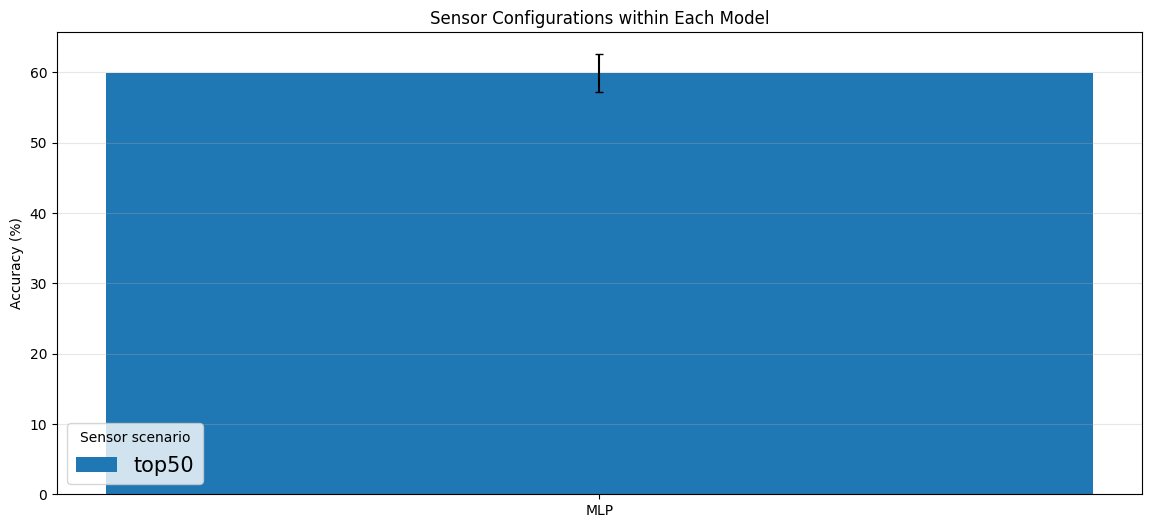

In [18]:
scenario_order = ["top50", "top100", "top150", "top200", "all"]
scenarios = [s for s in scenario_order if s in df["scenario"].unique()]

x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(14, 6))

for i, scenario in enumerate(scenarios):
    values = []

    for model in models:
        val = df[
            (df["model"] == model) &
            (df["scenario"] == scenario)
        ]["acc_mean"].values

        values.append(val[0] if len(val) > 0 else 0)

    plt.bar(
        x + i * width,
        values,
        width,
        yerr=[
            df[(df["model"] == m) & (df["scenario"] == scenario)]["acc_std"].values[0]
            if len(df[(df["model"] == m) & (df["scenario"] == scenario)]) > 0
            else 0
            for m in models
        ],
        capsize=3,
        label=scenario
    )

plt.xticks(x + width * (len(scenarios) - 1) / 2, models)
plt.ylabel("Accuracy (%)")
plt.title("Sensor Configurations within Each Model")
plt.legend(title="Sensor scenario", loc='lower left', fontsize = 15)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [21]:
results

[{'model': 'MLP',
  'results': {'top50': {'acc_mean': np.float64(59.91666666666667),
    'acc_std': np.float64(2.6536138880151086),
    'f1_mean': np.float64(0.5843857719617445),
    'f1_std': np.float64(0.024988112355410697),
    'recall_mean': np.float64(0.5991666666666666),
    'recall_std': np.float64(0.026536138880151102),
    'acc_runs': [56.25,
     56.25,
     58.333333333333336,
     62.5,
     60.416666666666664,
     56.25,
     60.416666666666664,
     58.333333333333336,
     62.5,
     60.416666666666664,
     60.416666666666664,
     58.333333333333336,
     58.333333333333336,
     54.166666666666664,
     58.333333333333336,
     58.333333333333336,
     60.416666666666664,
     62.5,
     64.58333333333333,
     62.5,
     62.5,
     58.333333333333336,
     62.5,
     60.416666666666664,
     64.58333333333333],
    'f1_runs': [0.5496077996077996,
     0.5564527260179435,
     0.5716875716875717,
     0.6064814814814814,
     0.5961445961445961,
     0.54537037037037

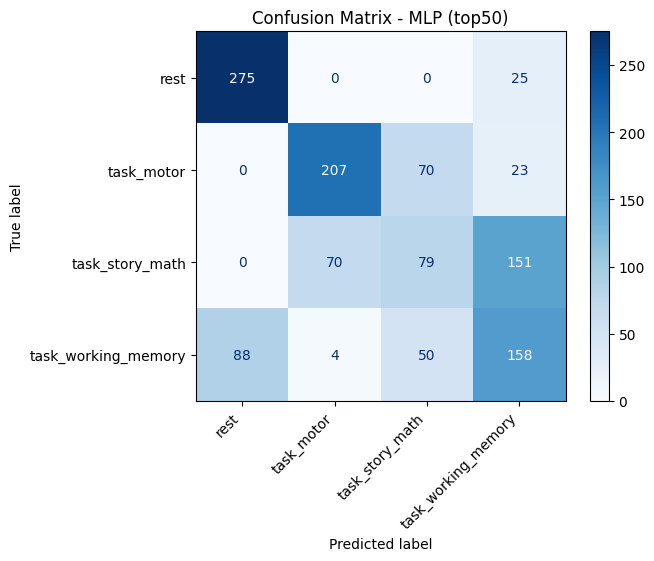

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from dataset import CLASS_NAMES

import matplotlib.pyplot as plt

for model in models:
    for scenario in scenarios:
        y_true = []
        y_pred = []

        for r in results:
            if r["model"] == model:
                stats = r["results"].get(scenario)
                if stats:
                    y_true = np.concatenate(stats["y_trues"])
                    y_pred = np.concatenate(stats["y_preds"])
                    break

        if len(y_true) > 0 and len(y_pred) > 0:
            cm = confusion_matrix(y_true, y_pred)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
            disp.plot(cmap='Blues')
            plt.xticks(rotation=45, ha='right')
            plt.title(f"Confusion Matrix - {model} ({scenario})")
            plt.show()

In [34]:
def evaluate_model_per_person(model, test_dataset, device=DEVICE, batch_size=8):
    model.to(device)
    model.eval()

    loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    per_person = {}

    with torch.no_grad():
        for x, y, person in loader:
            x = x.to(device)
            y = y.to(device)

            out = model(x)
            if isinstance(out, tuple) or isinstance(out, list):
                logits = out[0]
            else:
                logits = out

            preds = logits.argmax(dim=1).cpu().numpy()
            trues = y.cpu().numpy()
            persons = person.numpy()

            for pid, p, t in zip(persons, preds, trues):
                pid = int(pid)
                entry = per_person.setdefault(pid, {"correct": 0, "total": 0})
                entry["total"] += 1
                if p == int(t):
                    entry["correct"] += 1

    rows = [{"person": pid, "accuracy": (v["correct"] / v["total"]) * 100, "n_samples": v["total"]} for pid, v in per_person.items()]
    df_person = pd.DataFrame(rows).sort_values("person").reset_index(drop=True)
    return df_person

Training MLP with all sensors...


C:\Users\joybo\AppData\Local\Temp\ipykernel_18996\2921232683.py:40: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(train_loss)


Evaluating MLP for person 162935...
   person  accuracy  n_samples
0  162935      87.5         16
Evaluating MLP for person 707749...
   person  accuracy  n_samples
0  707749      25.0         16
Evaluating MLP for person 725751...
   person  accuracy  n_samples
0  725751      75.0          8
Evaluating MLP for person 735148...
   person  accuracy  n_samples
0  735148      62.5          8


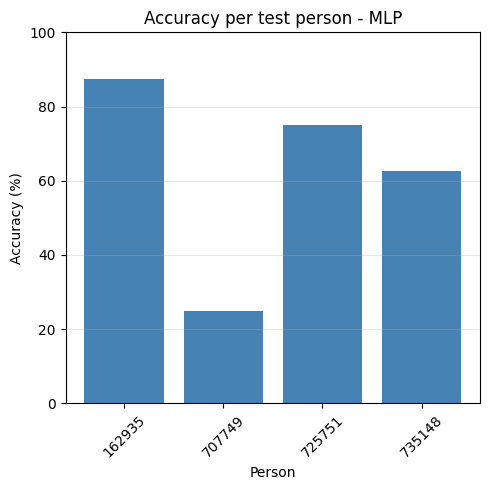

In [33]:
from torch import nn

from train import train_one_epoch
from torch.utils.data import Subset


sensor_scenarios_all = {
    "all": None,
    "top200": top200,
    "top150": top150,
    "top100": top100,
    "top50": top50,
}

def train_model(model, params, train_loader, device=DEVICE, epochs=25):
    model_kwargs = {
        k: v
        for k, v in params.items()
        if k not in ["learning_rate", "batch_size", "weight_decay"]
    }
    model = model(**model_kwargs).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["learning_rate"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
    )

    num_epochs = epochs

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        scheduler.step(train_loss)
    return model

def build_person_subsets(dataset, source_name):
    """Build subsets of the dataset grouped by person_id."""
    if dataset.person_ids is None:
        raise ValueError(f"{source_name} dataset must be created with add_person_id=True")

    grouped_indices = {}
    for index, person_id in enumerate(dataset.person_ids):
        grouped_indices.setdefault(int(person_id), []).append(index)

    return [
        (f"{source_name}_{person_id}", Subset(dataset, indices), person_id)
        for person_id, indices in sorted(grouped_indices.items())
    ]

for model in cross_model_configs:
    print(f"Training {model['name']} with all sensors...")
    trained_model = train_model(model["model_class"], model["params"], combined_train_loader, device=DEVICE)

    persons = build_person_subsets(cross_test_loader.dataset, "cross")
    per_person_results = []
    for person in persons:
        print(f"Evaluating {model['name']} for person {person[2]}...")
        df_person = evaluate_model_per_person(trained_model, person[1], device=DEVICE, batch_size=BATCH_SIZE)
        print(df_person)
        per_person_results.append((person[0], df_person))
    
    person_rows = []

    for _, df_person in per_person_results:
        if not df_person.empty:
            person_rows.append(df_person.iloc[0])

    person_acc_df = pd.DataFrame(person_rows).sort_values("person").reset_index(drop=True)

    plt.figure(figsize=(5, 5))
    plt.bar(person_acc_df["person"].astype(int).astype(str), person_acc_df["accuracy"], color="steelblue")
    plt.ylabel("Accuracy (%)")
    plt.xlabel("Person")
    plt.title(f"Accuracy per test person - {model['name']}")
    plt.ylim(0, 100)
    plt.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()